# Duolingo Stage 3: company operating diagnostics

Global public disclosures, **2024 Q3–2026 Q2**. Comparison bases: **2023 Q3–2024 Q2**, for YoY and the first main-quarter QoQ. External company context; no Video Call experiment or causal-effect estimate.

### Run the validated local analysis

Execute from the repository root. All sourced inputs must exist. No network requests. This cell regenerates three derivative CSVs, five PNGs and a validation JSON. Dependencies: analysis/requirements.txt.

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Markdown, HTML, Image

ROOT = Path.cwd().resolve()
if not (ROOT / 'docs/kpi_tree.md').is_file():
    raise RuntimeError('Execute with cwd set to the repository root.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from analysis.stage3_analysis import run_analysis, html_table, summary_markdown, MAIN_QUARTERS
result = run_analysis(ROOT)
print('Input QA:', result['inputs']['report']['status'], '| main quarters:', len(MAIN_QUARTERS), '| figures:', len(result['figures']))

Input QA: passed | main quarters: 8 | figures: 5


## tl;dr

This summary is computed only after input validation.

In [2]:
display(Markdown(summary_markdown(result)))

**Latest disclosed quarter: 2026 Q2.** DAU 58.7m (YoY +23.06%), MAU 140.6m; their quarterly-average ratio is 41.75%. Paid subscriptions are 12.7m paying accounts **at quarter end**. Subscription bookings are USD 250.316m **for the quarter**.

These are global company observations. Log identities and commercial ratios describe arithmetic; they do not establish Video Call effects, cohort retention, conversion, learning gains, or unit economics.

## Context & Methods

- DAU is quarterly mean daily users; MAU is quarterly mean monthly users. Their ratio is an analyst-derived participation-frequency proxy, not retention.
- Paid subscriptions are quarter-end paying accounts. Bookings and GAAP revenue are distinct quarterly flows.
- YoY/QoQ use sourced comparable bases. Whole-percent official YoY is reconciled with current/baseline rounding intervals and half the source's reported percentage step (0.5 percentage points for whole-percent disclosure); these bounds are not confidence intervals.
- The identity is 100 ln(DAU_t/DAU_base) = 100 ln(MAU_t/MAU_base) + 100 ln(ratio_t/ratio_base). Unit: **100 log growth points**, not percentage-point contributions, causal effects, or growth shares.

### Key Assumptions

Definitions and scope must remain comparable. Local checks establish input consistency, not original-source authenticity. Eight main quarters cannot identify seasonality or product effects. No regression or significance tests. Q4 annual-minus-YTD lineage is checked where used. For M008 no rounding interval is invented: its value is derived from DAU and MAU.

## Data

Inputs: company_quarterly_metrics.csv, company_comparison_baselines.csv, product_timeline.csv, metric_dictionary.csv and source_register.csv. Hashes and actual checks: analysis/stage3_validation.json. The table below includes only the eight main quarters.

In [3]:
lookup = result['inputs']['lookup']
company_rows = []
for year, quarter in MAIN_QUARTERS:
    row = {'quarter': f'{year} Q{quarter}'}
    for metric in ('M001', 'M002', 'M004', 'M005', 'M006', 'M007', 'M009'):
        row[metric] = f"{lookup[(year, quarter, metric)]['value']:.3f}"
    row['M008'] = f"{100 * lookup[(year, quarter, 'M008')]['value']:.2f}"
    company_rows.append(row)
display(HTML(html_table(company_rows, [
    ('quarter', 'Quarter'), ('M001', 'DAU (m avg)'), ('M002', 'MAU (m avg)'),
    ('M004', 'Paid (m end)'), ('M005', 'Sub bookings (USD m)'),
    ('M006', 'Total bookings (USD m)'), ('M007', 'Total revenue (USD m)'),
    ('M009', 'Sub revenue (USD m)'), ('M008', 'DAU/MAU (%)')],
    'Global company values; display digits do not imply extra measurement precision')))


Quarter,DAU (m avg),MAU (m avg),Paid (m end),Sub bookings (USD m),Total bookings (USD m),Total revenue (USD m),Sub revenue (USD m),DAU/MAU (%)
2024 Q3,37.200,113.100,8.600,176.300,211.500,192.594,157.600,32.89
2024 Q4,40.500,116.700,9.500,236.500,271.600,209.550,174.300,34.70
2025 Q1,46.600,130.200,10.300,232.200,271.600,230.743,191.000,35.79
2025 Q2,47.700,128.300,10.900,227.300,268.000,252.265,210.700,37.18
2025 Q3,50.500,135.300,11.500,240.270,281.919,271.713,229.491,37.32
2025 Q4,52.700,133.100,12.200,296.600,336.800,282.868,242.286,39.59
2026 Q1,56.500,137.800,12.500,268.100,308.500,291.967,250.908,41.00
2026 Q2,58.700,140.600,12.700,250.316,289.054,298.454,258.035,41.75


## Results

### 1. Active scale and frequency

The quarterly-average ratio is not cohort retention or feature adoption.

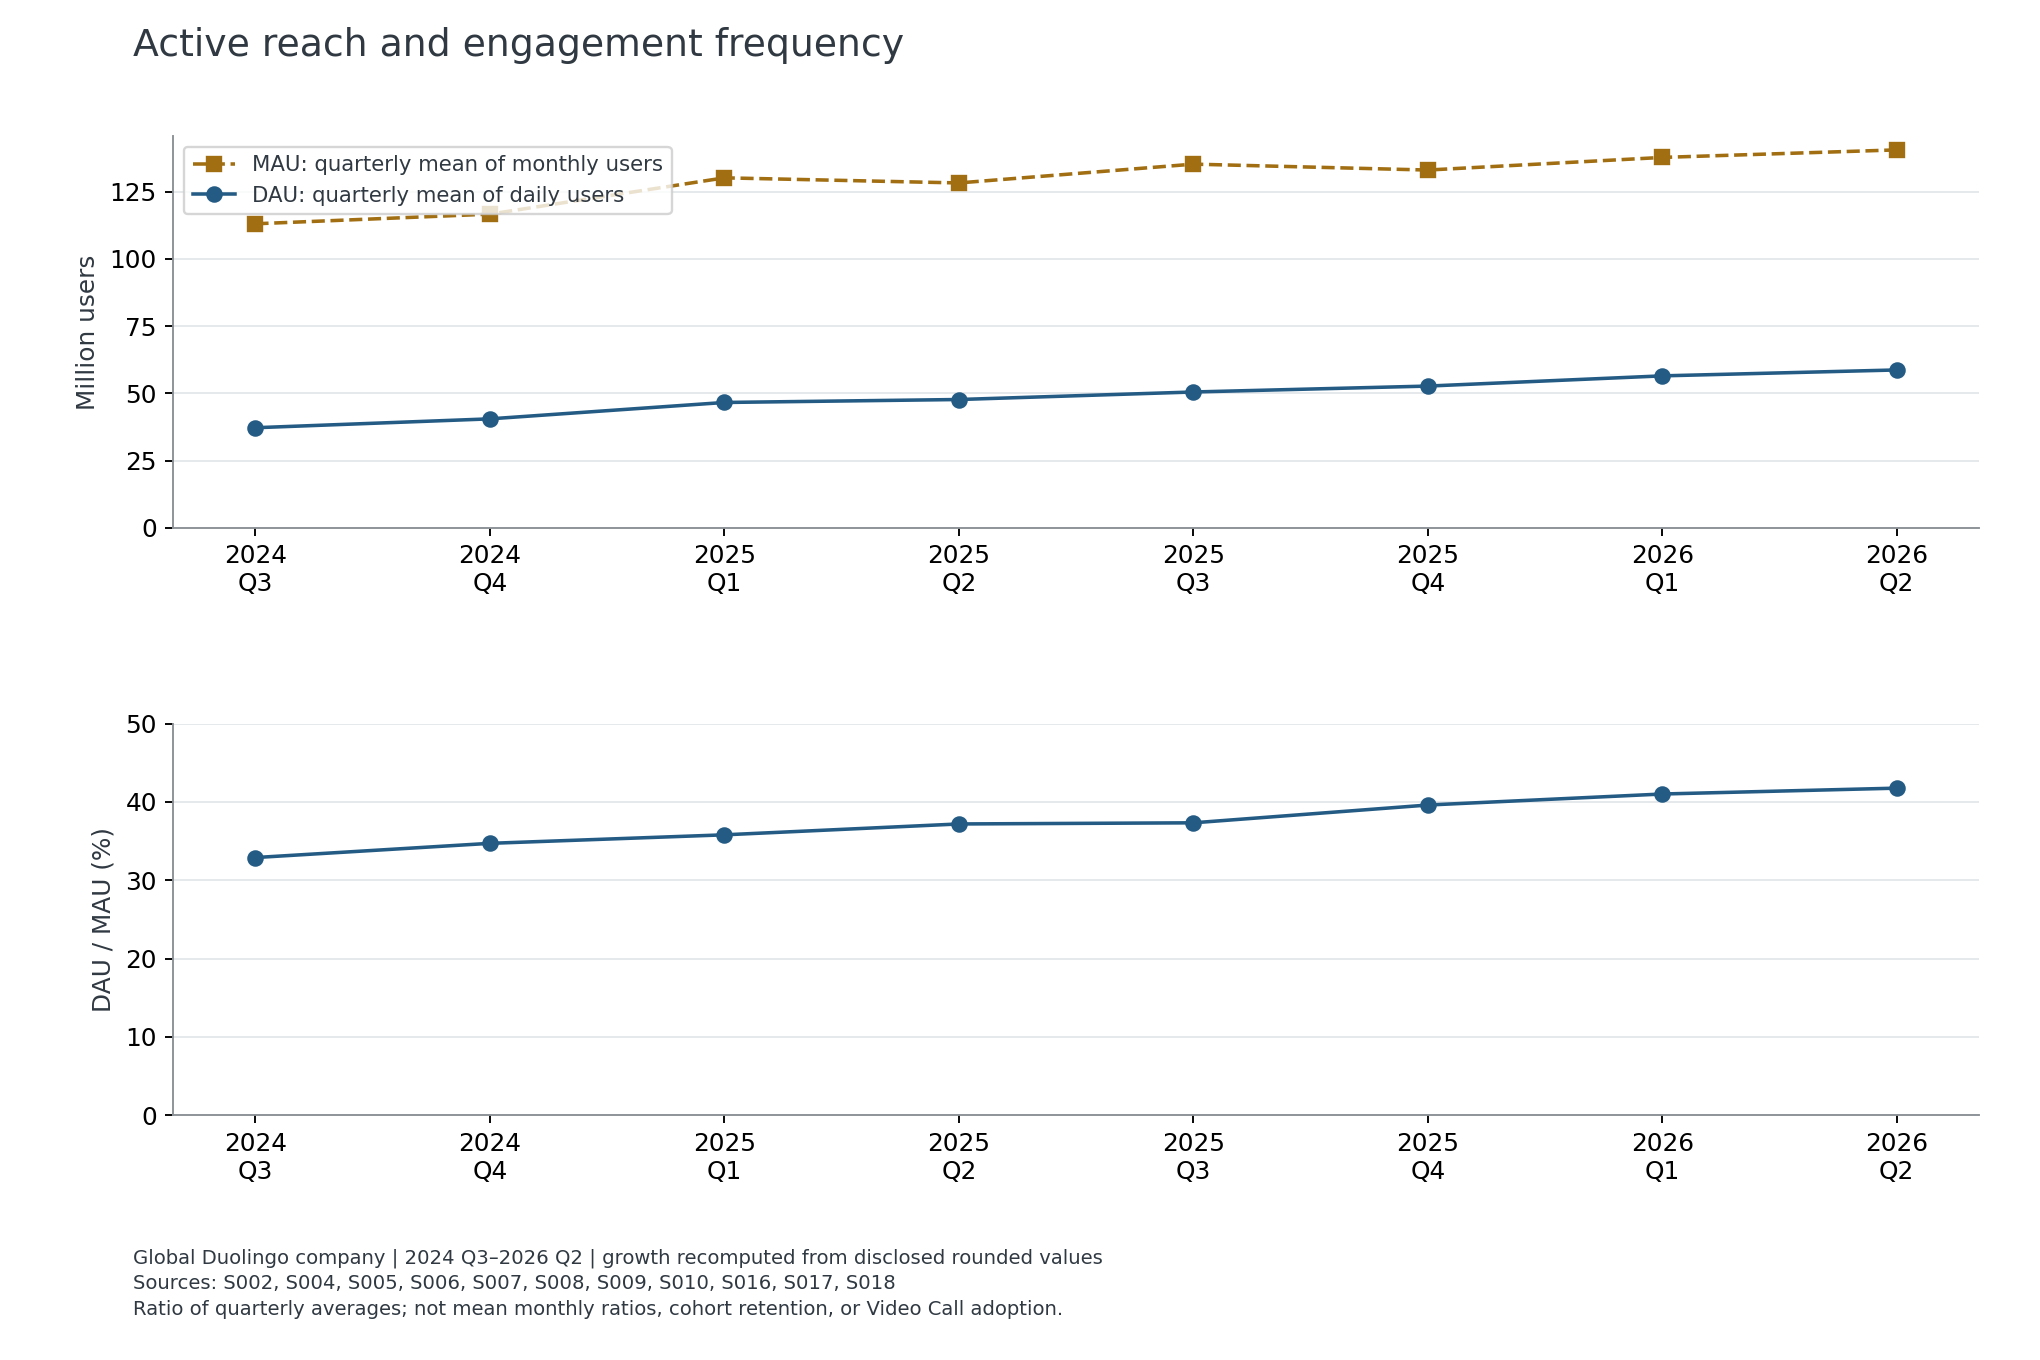

In [4]:
display(Image(filename=result['figures'][0]))

### 2. DAU growth decomposition

MAU and ratio components sum in log-growth units. This identity does not identify the causes of either component.

Quarter end,YoY base,DAU total,MAU component,Ratio component
2024-09-30,2023-09-30,42.996,30.823,12.173
2024-12-31,2023-12-31,40.918,27.773,13.144
2025-03-31,2024-03-31,39.479,28.819,10.660
2025-06-30,2024-06-30,33.563,21.383,12.180
2025-09-30,2024-09-30,30.566,17.922,12.644
2025-12-31,2024-12-31,26.331,13.149,13.182
2026-03-31,2025-03-31,19.264,5.673,13.591
2026-06-30,2025-06-30,20.751,9.155,11.596


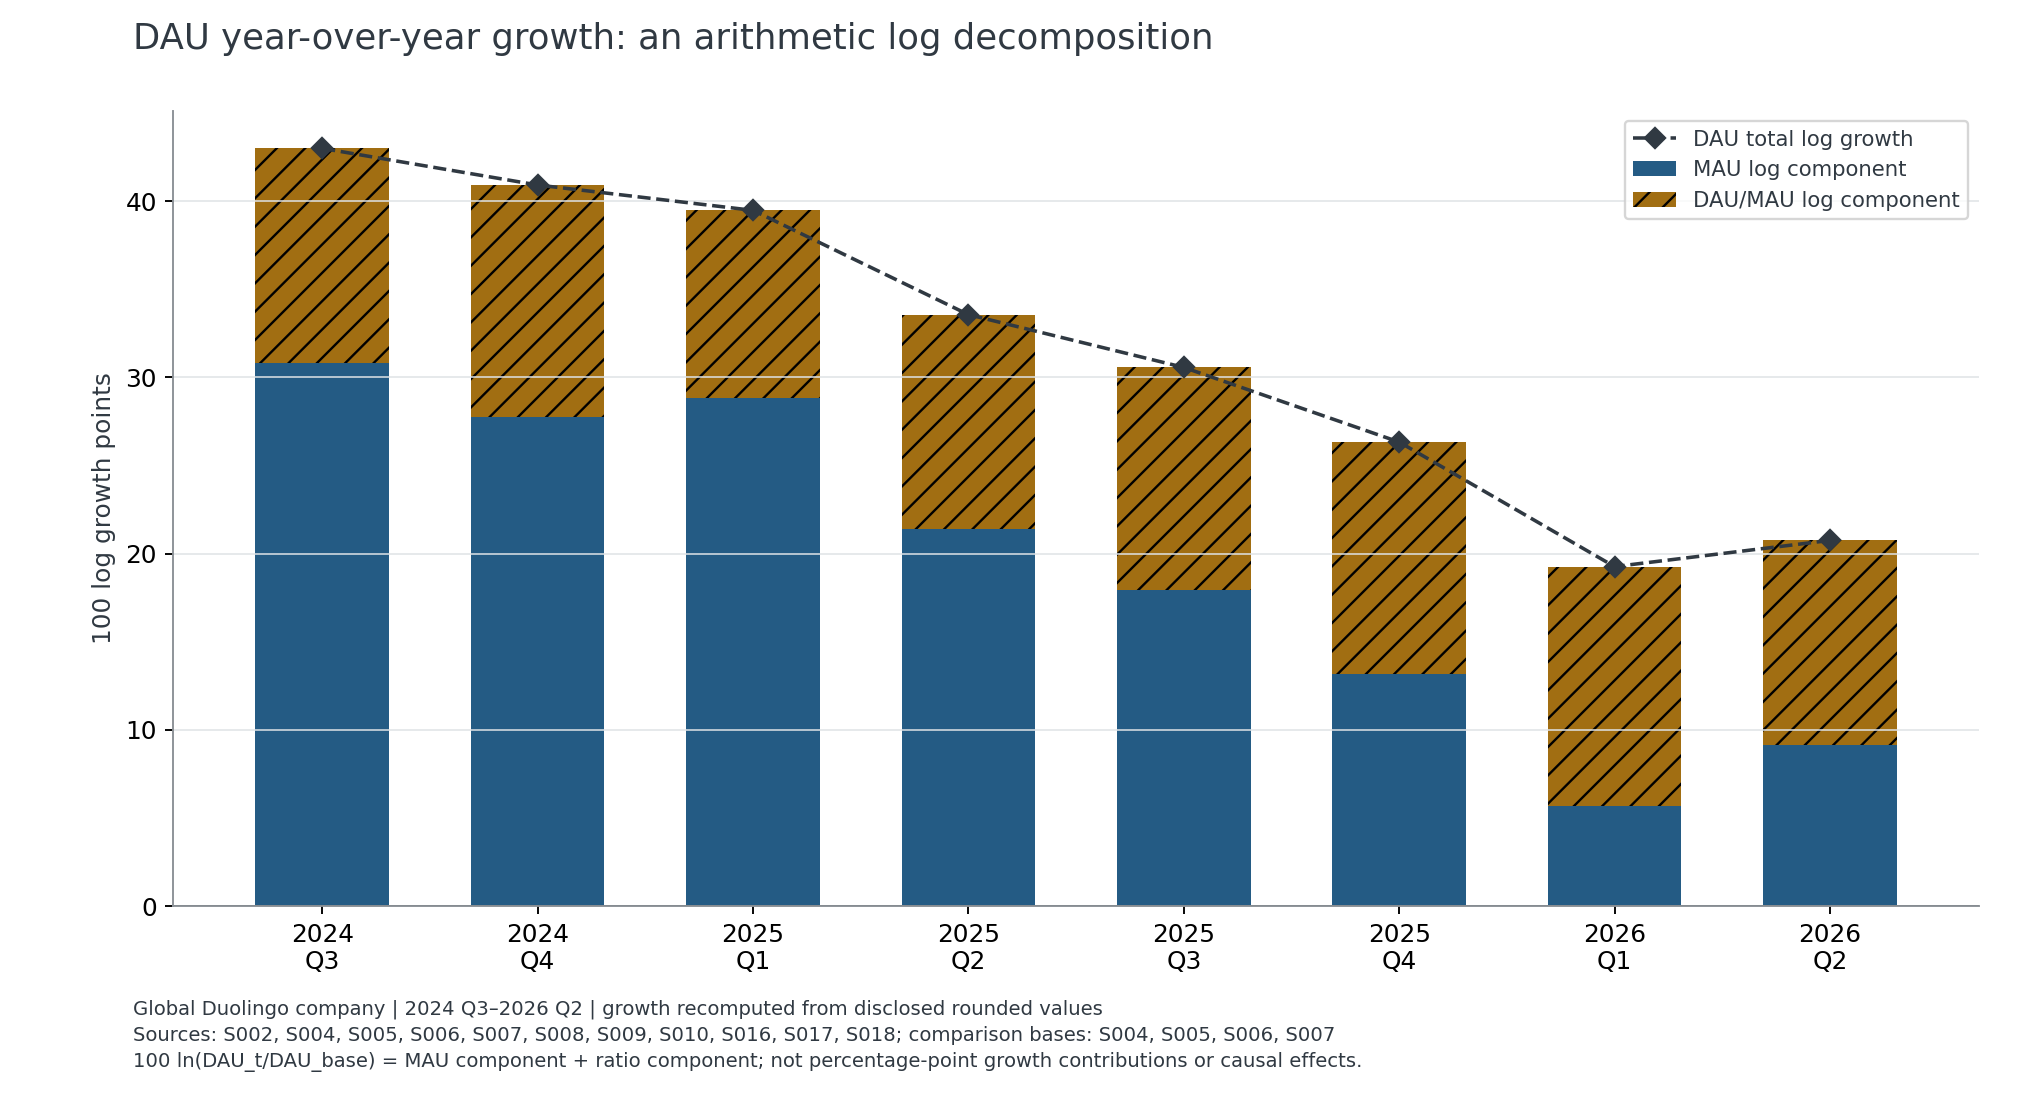

In [5]:
decomposition_rows = [
    {key: (f'{value:.3f}' if isinstance(value, float) else value)
     for key, value in row.items()}
    for row in result['tables']['engagement_decomposition'] if row['comparison'] == 'yoy']
display(HTML(html_table(decomposition_rows, [
    ('period_end', 'Quarter end'), ('baseline_period_end', 'YoY base'),
    ('dau_log_growth_points', 'DAU total'), ('mau_log_component_points', 'MAU component'),
    ('ratio_log_component_points', 'Ratio component')],
    'Unit: 100 log growth points; not percent growth or causal contributions')))
display(Image(filename=result['figures'][1]))

### 3. Paid stock and subscription demand

Stock and flows have different time bases. Conversion, renewal and price/mix effects are not identified.

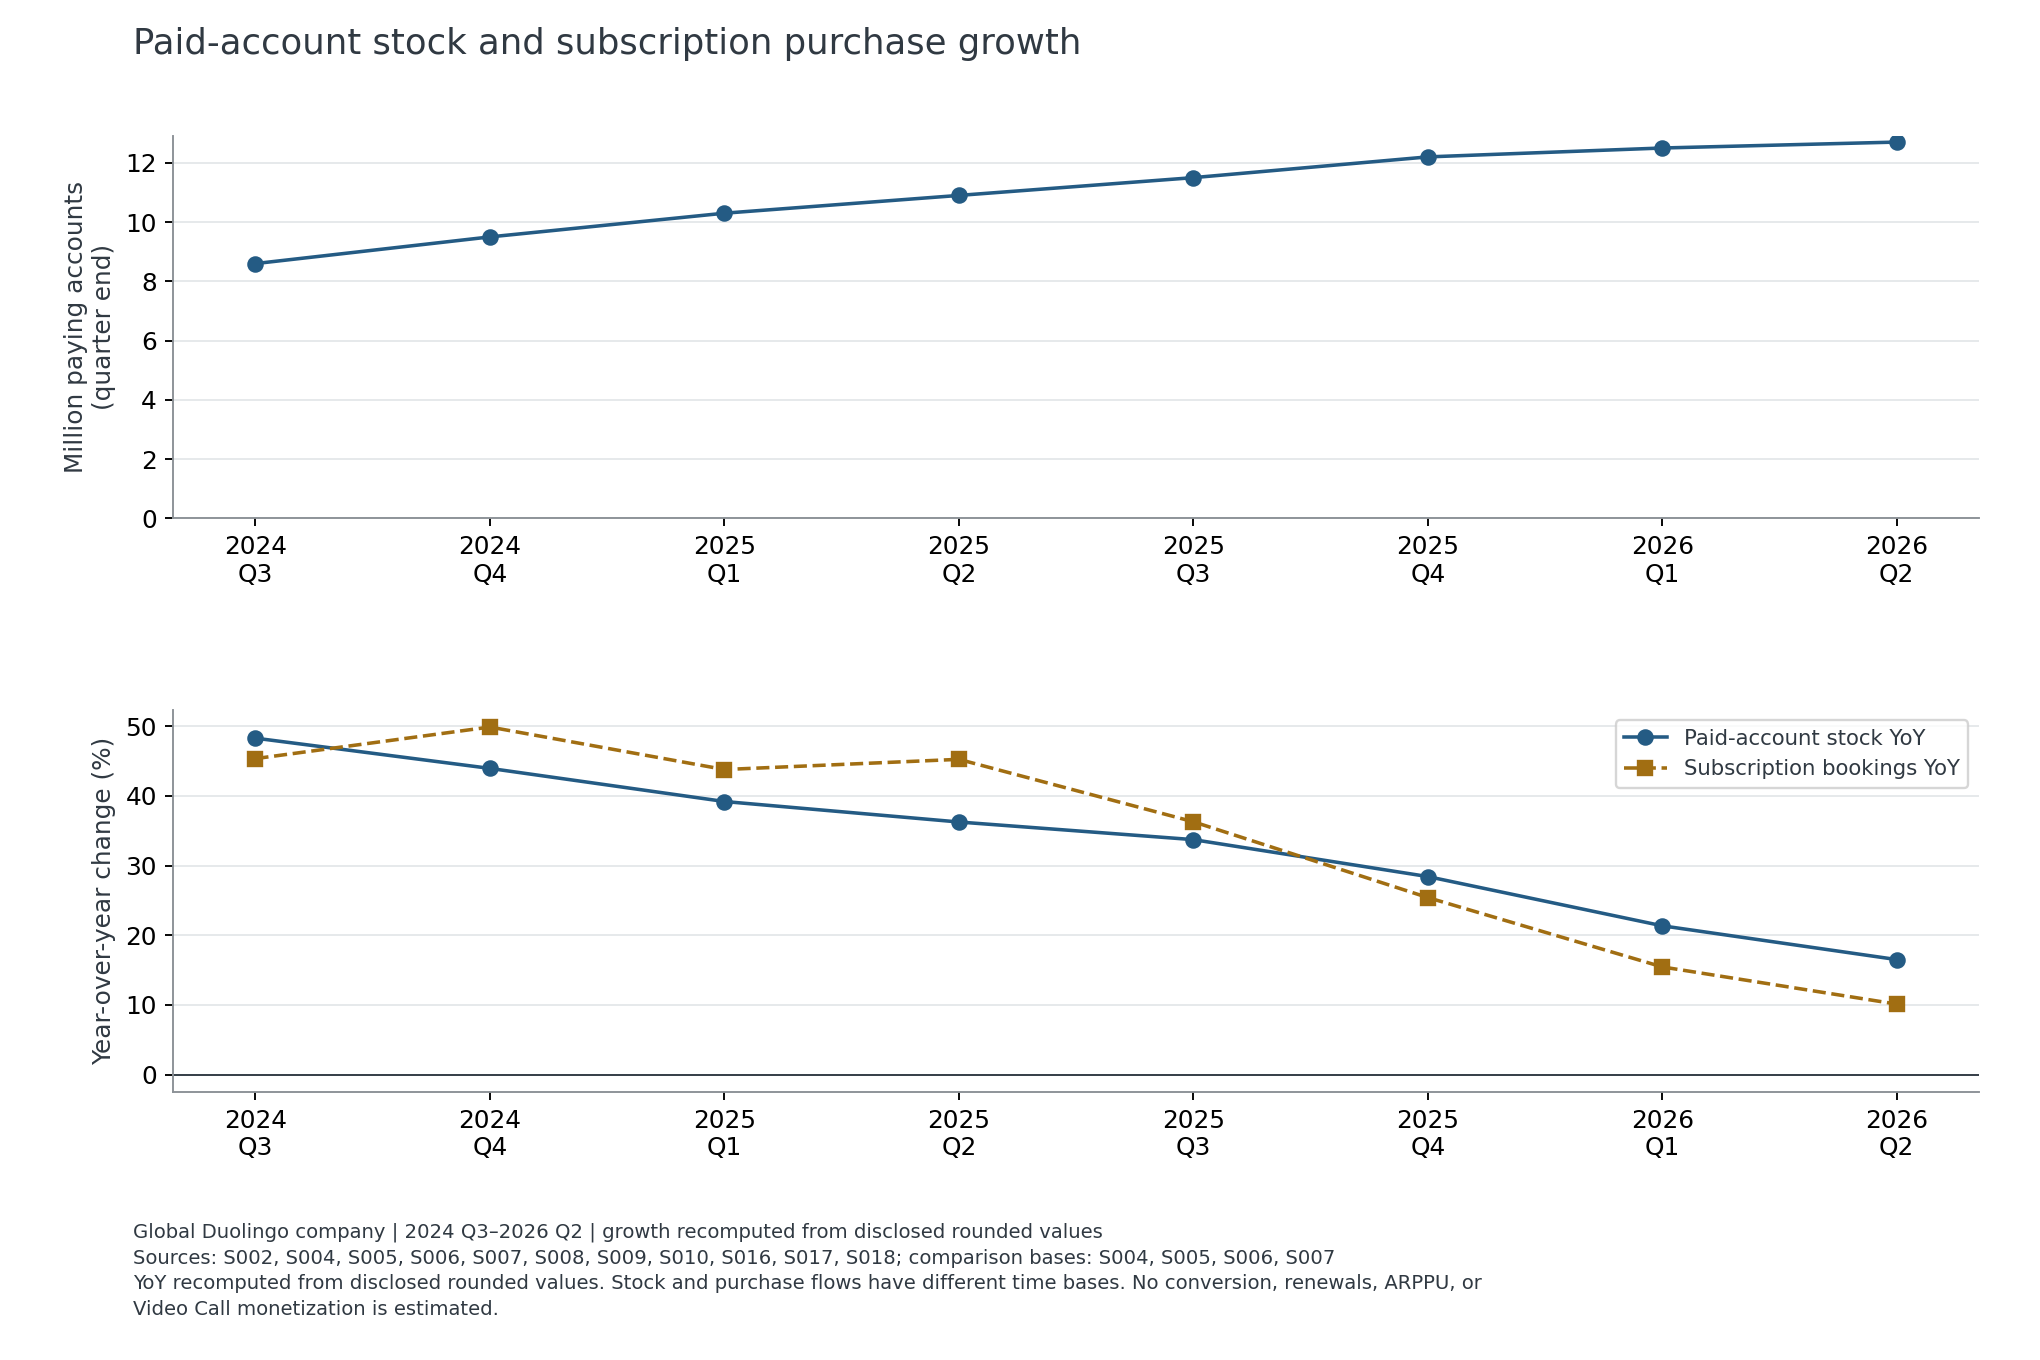

In [6]:
display(Image(filename=result['figures'][2]))

### 4. Purchase versus recognition timing

The descriptive flow gap does not reconcile deferred revenue, profit or cash flow.

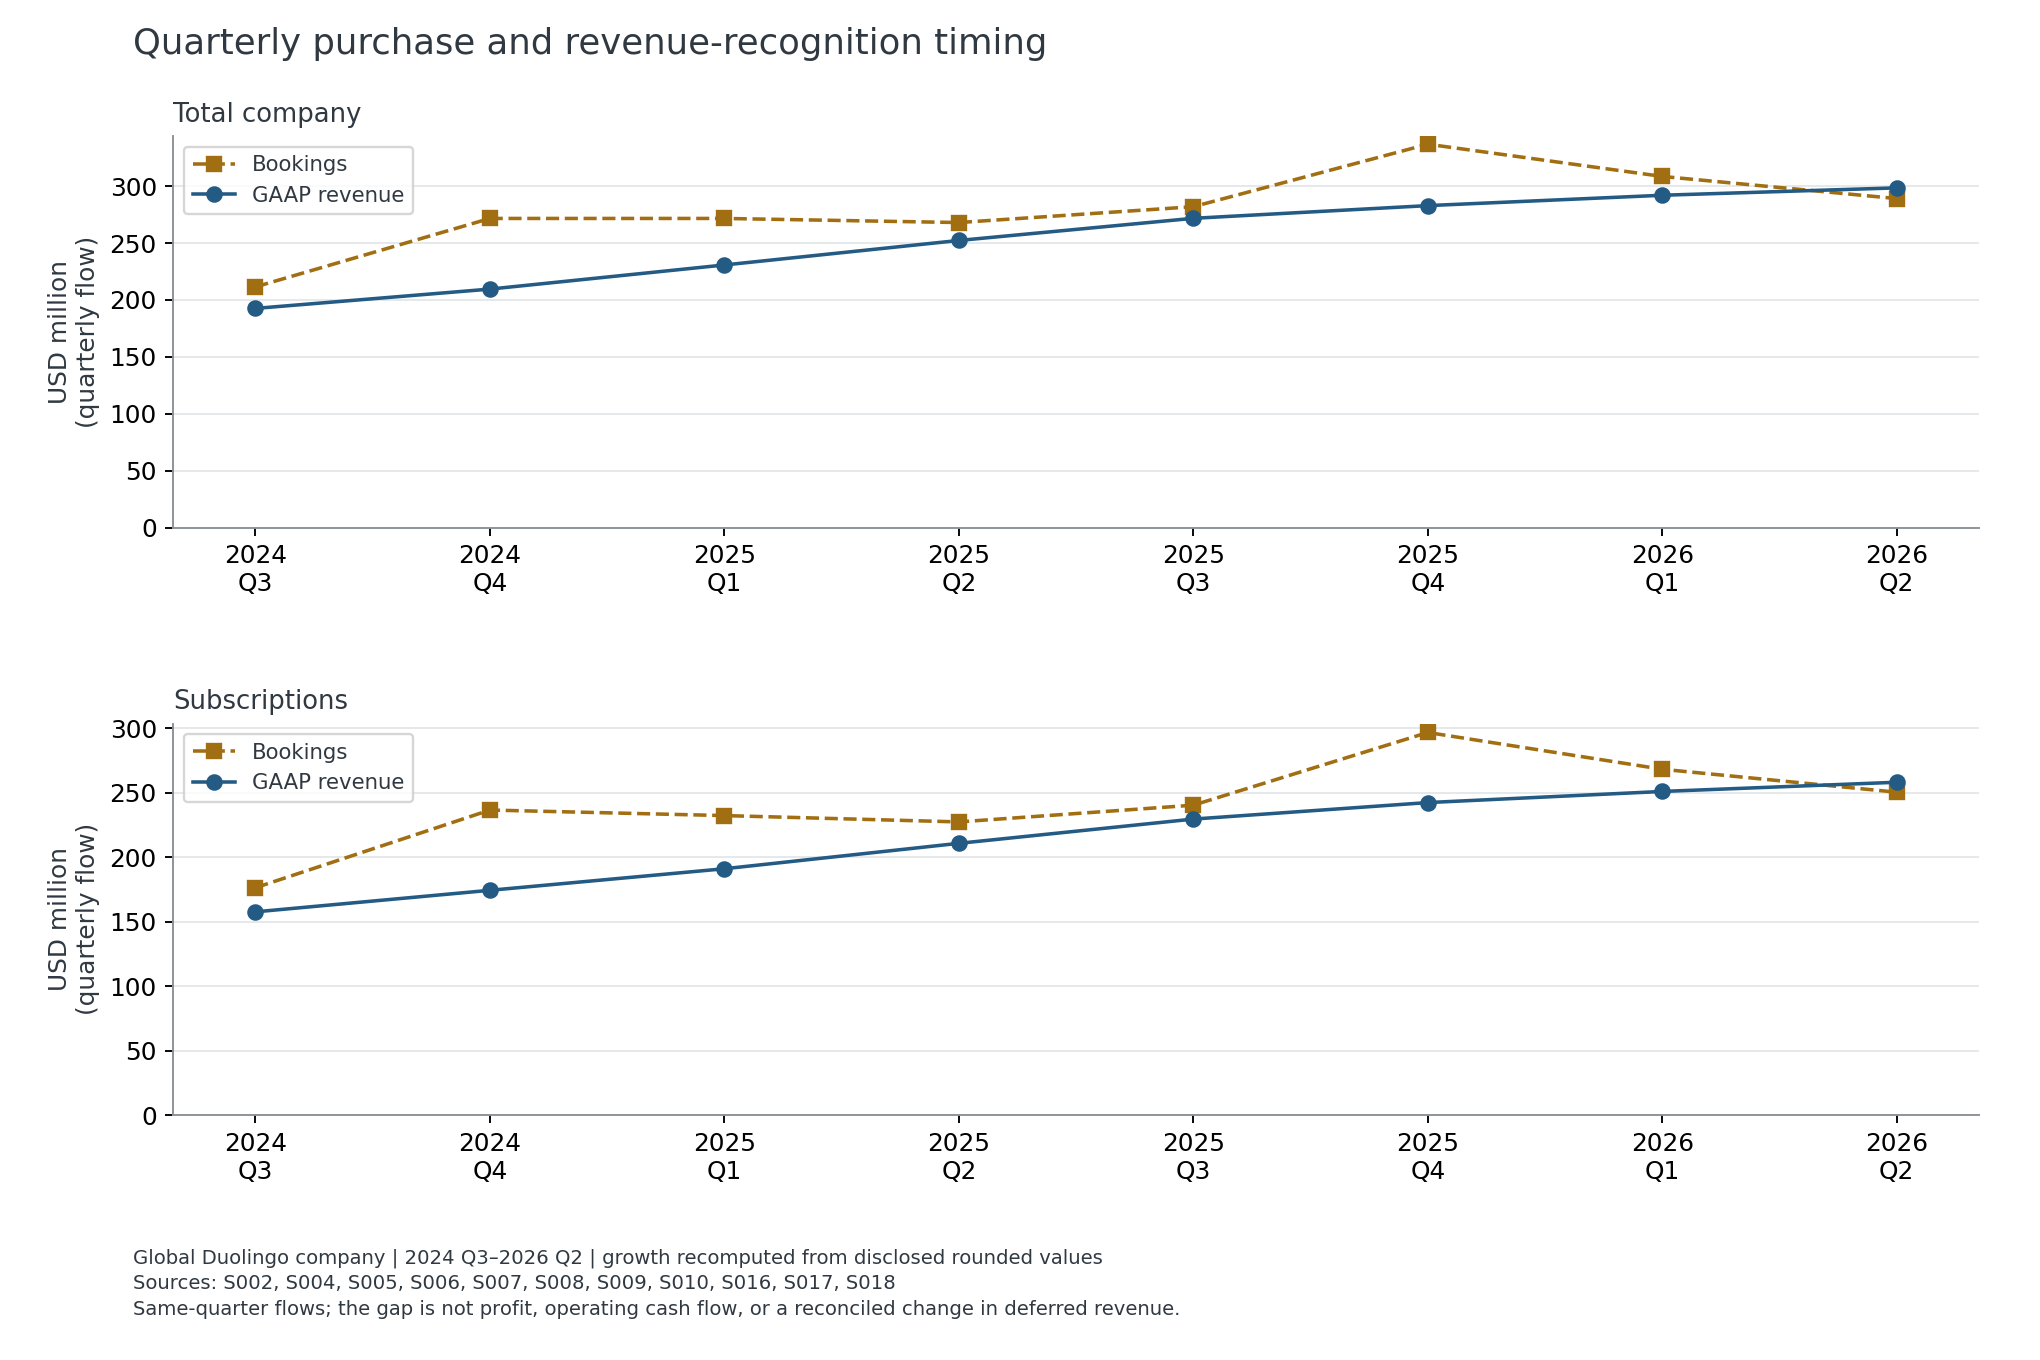

In [7]:
display(Image(filename=result['figures'][3]))

### 5. Subscription commercial structure

Each share uses its respective total-flow denominator.

Quarter end,Sub/total bookings (%),Sub/total revenue (%),Sub bookings/revenue
2024-09-30,83.357,81.830,1.119
2024-12-31,87.077,83.178,1.357
2025-03-31,85.493,82.776,1.216
2025-06-30,84.813,83.523,1.079
2025-09-30,85.227,84.461,1.047
2025-12-31,88.064,85.653,1.224
2026-03-31,86.904,85.937,1.069
2026-06-30,86.598,86.457,0.970


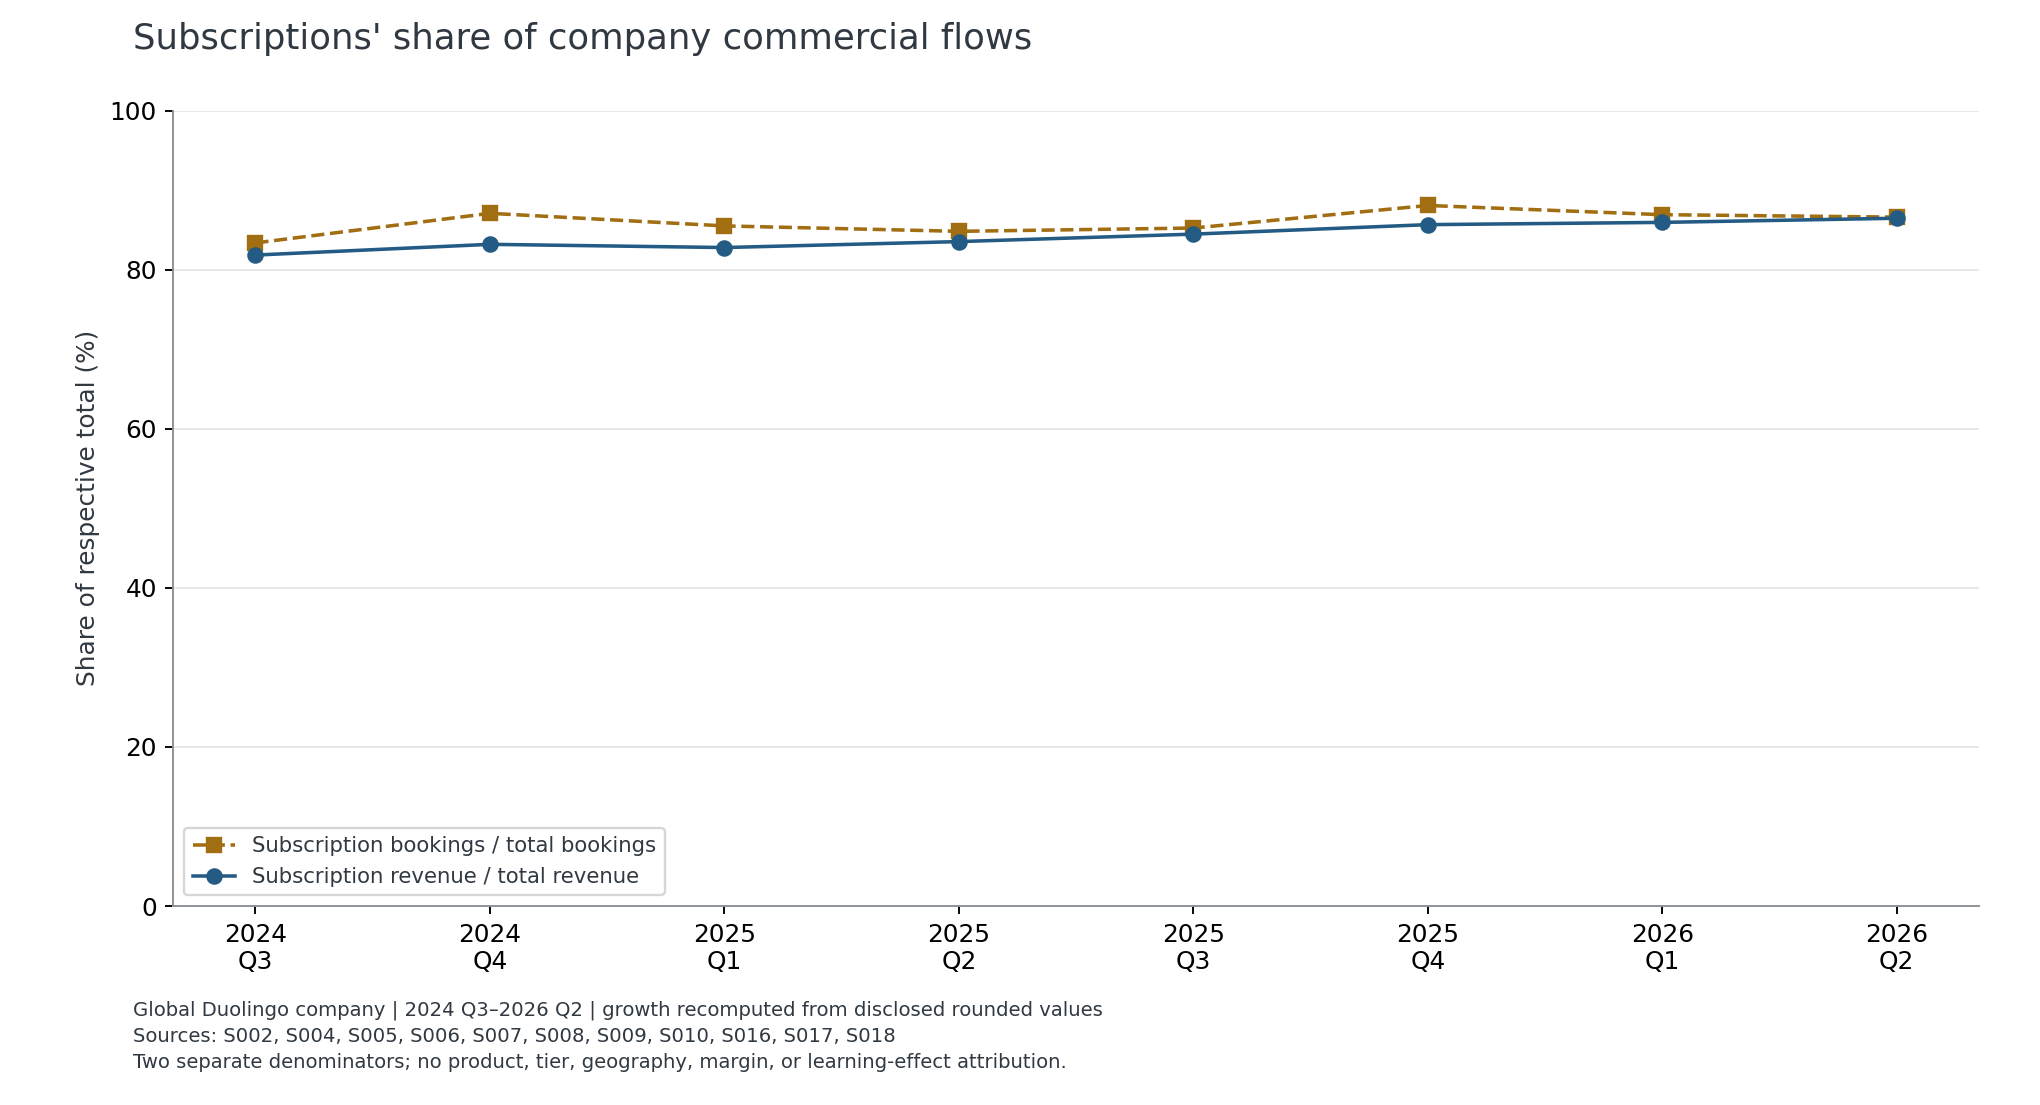

In [8]:
commercial_rows = [
    {key: (f'{value:.3f}' if isinstance(value, float) else value)
     for key, value in row.items()}
    for row in result['tables']['commercial_structure']]
display(HTML(html_table(commercial_rows, [
    ('period_end', 'Quarter end'),
    ('subscription_share_of_total_bookings_pct', 'Sub/total bookings (%)'),
    ('subscription_share_of_total_revenue_pct', 'Sub/total revenue (%)'),
    ('subscription_bookings_to_subscription_revenue_ratio', 'Sub bookings/revenue')],
    'Commercial composition; not feature conversion or profit')))
display(Image(filename=result['figures'][4]))

### Product disclosures, sources and QA

Events retain actual-date precision, reported dates and management claim labels. Concurrent business movement is not causality. CURR stays a dated limited disclosure; it is never filled into an eight-quarter series.

In [9]:
display(HTML(html_table(result['inputs']['timeline'], [
    ('event_id', 'Event'), ('event_date', 'Date'), ('event_date_precision', 'Precision'),
    ('event_window_start', 'Window start'), ('event_window_end', 'Window end'),
    ('reported_on', 'Reported'), ('feature', 'Feature'), ('tier', 'Tier'),
    ('rollout_scope_text', 'Disclosure'), ('claim_type', 'Claim type'),
    ('source_id', 'Sources')], 'Sourced disclosures; missing exact dates stay missing')))
used_ids = {source_id for row in result['inputs']['quarterly'] + result['inputs']['baselines'] + result['inputs']['timeline']
    for source_id in row['source_id'].split('|')}
source_rows = [{'source_id': source_id, 'title': source['title'], 'url': source['url']}
    for source_id, source in result['inputs']['sources'].items() if source_id in used_ids]
display(HTML(html_table(source_rows, [('source_id', 'ID'), ('title', 'Original source'), ('url', 'URL')], 'Source register links')))
qa_rows = [{'check': name, 'status': check['status'], 'evaluations': check['evaluations']}
    for name, check in result['inputs']['report']['checks'].items()]
display(HTML(html_table(qa_rows, [('check', 'Check'), ('status', 'Status'), ('evaluations', 'Evaluations')], 'Actual local input and identity checks')))


Event,Date,Precision,Window start,Window end,Reported,Feature,Tier,Disclosure,Claim type,Sources
E2024Q3_01,2024Q3,quarter,2024-07-01,2024-09-30,2024-11-06,Video Call,Max,Q3宣布Video Call进入Max，支持与Lily对话。,official_product_announcement,S004
E2024Q3_02,2024-09-30,day,,,2024-11-06,Duolingo Max,Max,Q3期末Max可购买范围约覆盖一半DAU。,official_qualitative_rollout,S004
E2024Q3_03,,unknown,,,2024-11-06,Video Call,Max,披露时Video Call可供几乎全部Max订阅者使用。,official_qualitative_rollout,S004
E2024Q4_01,,unknown,,,2025-02-27,Duolingo Max,Max,披露时Max可购买范围已覆盖多数用户。,official_qualitative_rollout,S005
E2024Q4_02,2024-12-31,day,,,2025-02-27,Duolingo Max,Max,年末Max占全部付费订阅者5%。,official_numeric_mix_disclosure,S005
E2025Q1_01,,unknown,,,2025-05-01,Video Call practice tab,Max,计划未来数月加入对话回顾和Lily语音信息。,official_product_plan,S006
E2025Q1_02,,unknown,,,2025-05-01,Video Call 3D experience,Max,公司正添加3D Lily、互动背景和动画。,official_product_development,S006
E2025Q2_01,,unknown,,,2025-08-06,Duolingo Max,Max,公司称Max在披露前不足一年完成铺开。,official_qualitative_rollout,S007
E2025Q2_02,,unknown,,,2025-08-06,Video Call enhancements,Max,未来改进包括游戏化、互动背景及适合者更长通话。,official_product_plan,S007
LATE_E01,,unknown,,,2025-11-05,Video Call / Max,Max,公司披露已引入引导式Video Call，期待提升Max采用。,company_disclosed_event,S008


ID,Original source,URL
S001,Q2 2026 shareholder letter,https://www.sec.gov/Archives/edgar/data/1562088/000162828026053299/q2fy26duolingo6-30x26share.htm
S002,Q2 2026 Form 10-Q,https://www.sec.gov/Archives/edgar/data/1562088/000162828026053603/duol-20260630.htm
S004,Q3 2024 shareholder letter,https://www.sec.gov/Archives/edgar/data/1562088/000156208824000248/q3fy24duolingo09-30x24shar.htm
S005,Q4 2024 shareholder letter,https://www.sec.gov/Archives/edgar/data/1562088/000156208825000039/q4fy24duolingo12-31x24shar.htm
S006,Q1 2025 shareholder letter,https://www.sec.gov/Archives/edgar/data/1562088/000156208825000098/q1fy25duolingo3-31x25share.htm
S007,Q2 2025 shareholder letter,https://www.sec.gov/Archives/edgar/data/1562088/000156208825000165/q2fy25duolingo6-30x25share.htm
S008,Q3 2025 shareholder letter,https://www.sec.gov/Archives/edgar/data/1562088/000162828025049514/q3fy25duolingo9-30x25share.htm
S009,Q4 2025 shareholder letter,https://www.sec.gov/Archives/edgar/data/1562088/000162828026012246/q4fy25duolingo12-31x25shar.htm
S010,Q1 2026 shareholder letter,https://www.sec.gov/Archives/edgar/data/1562088/000162828026029790/q1fy26duolingo3-31x26share.htm
S016,Q1 2026 Form 10-Q,https://www.sec.gov/Archives/edgar/data/1562088/000162828026029976/duol-20260331.htm


Check,Status,Evaluations
source_register_unique_id,passed,1
metric_dictionary_unique_id,passed,1
dictionary_metric_coverage,passed,1
required_values,passed,92
numeric_and_date_parse,passed,92
quarter_boundaries,passed,92
disclosure_access_dates,passed,92
finite_positive_values,passed,92
metric_fk,passed,92
unit_and_aggregation,passed,92


## Takeaways

The derivative tables establish company operating context. The companion business review owns at most three evidence-labelled Driver hypotheses and alternative explanations. Stage 2 H1/H2 mechanisms and VOC counterexamples guide future tests and guardrails; self-selected theme counts do not explain company movements. Stage 4 must label adoption, incremental retention/conversion, cannibalization and AI cost as unknown scenario parameters. Stage 5 needs real randomized events.

**Jupyter rebuild:** python scripts/run_stage3.py --execute

**Fresh Python process rebuild (no Jupyter kernel):** python scripts/run_stage3.py --execute-direct

**Read-only input QA:** python scripts/run_stage3.py --check-only